<a href="https://colab.research.google.com/github/LuisManuelCatzoliSoriano/Simulaci-n_II/blob/main/Metodo_del_Kernel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma, norm

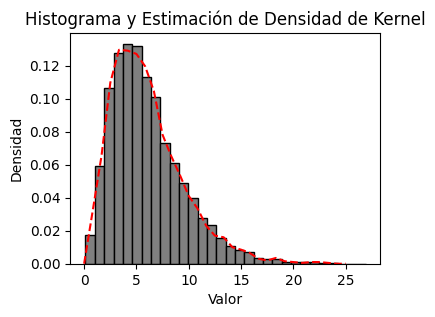

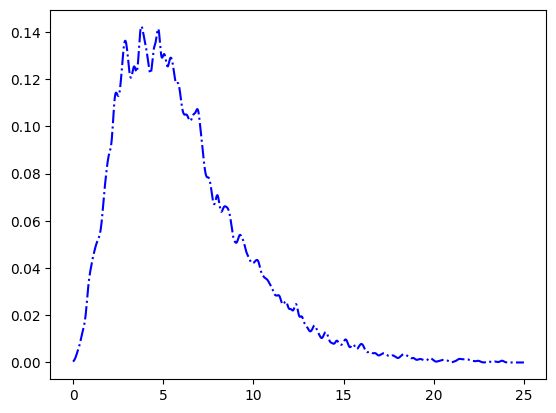

In [15]:
def k2(u):
  return (1/(np.sqrt(2*np.pi)))*np.exp(-(u**2)/2) # Se añadió el paréntesis de cierre y np.pi
def k1(u):
  return (1/(np.sqrt(2*np.pi)))*np.exp(-(u**2)/2) # Se añadió np.pi
def k(u):
  if abs(u) < 1: # Se corrigió 'menor que' a '<'
    return 1/2
  else:
    return 0

def est(x,h,l, kernel_func=k): # Se añadió kernel_func con k como valor por defecto
  suma=0
  n=len(l)
  for i in range(n):
    suma = suma + kernel_func((x - l[i]) / h) # Se usa kernel_func en lugar de k
  return suma / (n * h) # Se añadió el retorno correcto para la estimación de densidad

a=3
scale_param=2 # Se renombró 'b' a 'scale_param' para evitar conflictos
N=10000
l=gamma.rvs(a,0,scale_param,N)

# Se corrigió la lógica del bucle 'while' y la creación de la lista de puntos de evaluación
evaluation_points = []
current_point = 0.0
# Se asume que se quiere generar puntos desde 0 hasta 25, con incrementos de 25/30
while current_point <= 25:
  evaluation_points.append(current_point)
  current_point += 25/30

h=0.1
f=[]
for x in evaluation_points: # Se usó la nueva lista de puntos de evaluación
  f.append(est(x,h,l)) # Ahora llama a est con el kernel por defecto 'k'

plt.figure(figsize=(4,3))
plt.hist(l,density=1,bins=30, color='gray',edgecolor='black')
plt.plot(evaluation_points, f, color='red', linestyle='--') # Se añadió la curva de densidad estimada
plt.title('Histograma y Estimación de Densidad de Kernel')
plt.xlabel('Valor')
plt.ylabel('Densidad')
plt.show()
x=np.linspace(0,25,1000)
f_k2=np.zeros(1000) # Se cambió el nombre de la variable para no sobrescribir la anterior
for i in range(1000):
  f_k2[i]=est(x[i],h,l,k2) # Se corrigió el error pasando x[i] en lugar de todo el array x, y k2 como kernel
plt.plot(x,f_k2, color='blue', linestyle='-.') # Se usa f_k2 para plotear
plt.show()

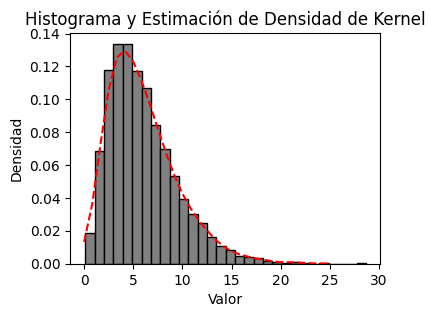

In [43]:
def k2(u):
  return (1/(np.sqrt(2*np.pi)))*np.exp(-(u**2)/2) # Se añadió el paréntesis de cierre y np.pi
def k1(u):
  return (1/(np.sqrt(2*np.pi)))*np.exp(-(u**2)/2) # Se añadió np.pi
def k(u):
  if abs(u) < 1: # Se corrigió 'menor que' a '<'
    return 1/2
  else:
    return 0

def est(x,h,l, kernel_func=k): # Se añadió kernel_func con k como valor por defecto
  suma=0
  n=len(l)
  for i in range(n):
    suma = suma + kernel_func((x - l[i]) / h) # Se usa kernel_func en lugar de k
  return suma / (n * h) # Se añadió el retorno correcto para la estimación de densidad

a=3
scale_param=2 # Se renombró 'b' a 'scale_param' para evitar conflictos
N=10000
l=gamma.rvs(a,0,scale_param,N)

# Se corrigió la lógica del bucle 'while' y la creación de la lista de puntos de evaluación
evaluation_points = []
current_point = 0.0
# Se asume que se quiere generar puntos desde 0 hasta 25, con incrementos de 25/30
while current_point <= 25:
  evaluation_points.append(current_point)
  current_point += 25/30

h=1.06*np.std(l)/np.sqrt(N**(1/5))
f=[]
for x in evaluation_points: # Se usó la nueva lista de puntos de evaluación
  f.append(est(x,h,l)) # Ahora llama a est con el kernel por defecto 'k'

plt.figure(figsize=(4,3))
plt.hist(l,density=1,bins=30, color='gray',edgecolor='black')
plt.plot(evaluation_points, f, color='red', linestyle='--') # Se añadió la curva de densidad estimada
plt.title('Histograma y Estimación de Densidad de Kernel')
plt.xlabel('Valor')
plt.ylabel('Densidad')
plt.show()

Euler murayama

In [2]:
from random import gauss, seed
from math import sqrt,log
from scipy.stats import gaussian_kde

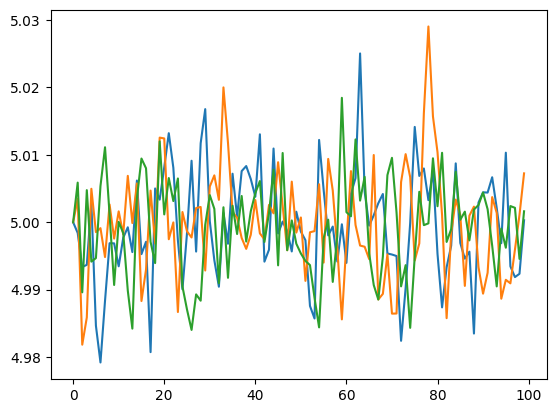

In [39]:
def tray(x0,c,u,o,delta,N):
  l=np.zeros(N)
  l[0]=x0
  for i in range(N-1):
    x=l[i]
    t=0
    oo=sqrt(delta)
    while t < 1:
      w=oo*gauss(0,1)
      x=x+c*(x-u)*delta+o*w
      t=t+delta
    l[i+1]=x
  return l
c=-.9
u=5
o=0.01
x0=u
delta=0.01
N=100
for i in range(3):
 l=tray(x0,c,u,o,delta,N)
 plt.plot(l)
plt.show()

In [ ]:
import numpy as np # Importar numpy para np.zeros
import matplotlib.pyplot as plt # Importar matplotlib para plt.plot y plt.show

def tray(x0,c,u,o,delta,N):
  l=np.zeros(N)
  l[0]=x0
  for i in range(N-1):
    x=l[i]
    t=0
    oo=sqrt(delta)
    while t < 1:
      w=oo*gauss(0,1)
      x=x+c*(x-u)*delta+o*w
      t=t+delta
    l[i+1]=x
  return l
def ver(l_trajectory,c,u,o,delta): # Renombrado 'l' a 'l_trajectory' para mayor claridad
  suma=0
  oo=sqrt(delta)
  n=len(l_trajectory)
  ns=100000
  sim=np.zeros(ns)
  for i in range(n-1):
    for j in range(ns):
     x=l_trajectory[i]
     t=0
     while t < 1:
        w=oo*gauss(0,1)
        x=x+c*(x-u)*delta+o*w
        t=t+delta
     sim[j]=x
    pdf=gaussian_kde(sim)
    valor=pdf(l_trajectory[i+1])[0]
    suma=suma+log(valor)
  return suma/ns

seed(43)
c=-.9
u=5
o=0.01
x0=u
delta=0.01
N=100

# Primero, generar la trayectoria usando la función tray
l_generated = tray(x0, c, u, o, delta, N)

# Luego, pasar la trayectoria generada a la función ver
ver_output = ver(l_generated, c, u, o, delta)

print(ver_output)